In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import os
import seaborn as sns
from torch.utils.tensorboard import SummaryWriter
import datetime
from sklearn.metrics import silhouette_score
import plotly.express as px
from sklearn.metrics import silhouette_samples, silhouette_score

In [9]:
pip install gdown

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import os
import gdown

# Google Drive file ID from the provided link
file_id = '1Uksjnwy-UEQvqF-0TKbOT6J_s5tXfkMm'
output_path = 'cleaned_data.csv'

ruta_limpia = os.path.abspath(output_path)

gdown.download(id=file_id, output=ruta_limpia, quiet=False)


FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\User\\Documents\\GitHub\\SIAE\\notebooks\\cleaned_data.csv94nvpxrt.part'

In [ ]:
import pandas as pd

df = pd.read_csv('cleaned_data.csv', encoding='utf-8')
display(df.head())


,id_diagnostico,sector,tamano_empresa,porcentaje_procesos_documentados,presupuesto_anual_tecnología,respuesta_texto,nivel_madurez,recomendacion_principal
0,DIAG_0000,Tecnología,Micro,0.05,3000000.0,"El trabajo es muy empírico, no hay documentaci...",Inicial,Mapear flujos de trabajo de desarrollo y usar ...
1,DIAG_0001,Tecnología,Grande,0.81,261000000.0,"Todo está automatizado, usamos datos para mejo...",Optimizado,Aplicar MLOps y analítica predictiva para opti...
2,DIAG_0002,Tecnología,Pequeña,0.27,47000000.0,Hay guías básicas pero no siempre se cumplen l...,En Desarrollo,Integrar herramientas de tickets con repositor...
3,DIAG_0003,Tecnología,Pequeña,0.30,19000000.0,Hay guías básicas pero no siempre se cumplen l...,En Desarrollo,Integrar herramientas de tickets con repositor...
4,DIAG_0004,Manufactura,Micro,0.08,6000000.0,"Todo es manual, dependemos de una sola persona...",Inicial,Estandarizar el registro diario de mermas e in...


### Información general del DataFrame

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_diagnostico                    3000 non-null   object 
 1   sector                            3000 non-null   object 
 2   tamano_empresa                    3000 non-null   object 
 3   porcentaje_procesos_documentados  3000 non-null   float64
 4   presupuesto_anual_tecnología      3000 non-null   float64
 5   respuesta_texto                   3000 non-null   object 
 6   nivel_madurez                     3000 non-null   object 
 7   recomendacion_principal           3000 non-null   object 
dtypes: float64(2), object(6)
memory usage: 187.6+ KB
None


### Estadísticas descriptivas de las columnas numéricas

In [ ]:
display(df.describe(include='all'))

,id_diagnostico,sector,tamano_empresa,porcentaje_procesos_documentados,presupuesto_anual_tecnología,respuesta_texto,nivel_madurez,recomendacion_principal
count,3000,3000,3000,3000.000000,3.000000e+03,3000,3000,3000
unique,3000,4,4,NaN,NaN,32,4,16
top,DIAG_2999,Tecnología,Grande,NaN,NaN,Hay guías básicas pero no siempre se cumplen l...,En Desarrollo,Integrar herramientas de tickets con repositor...
freq,1,797,779,NaN,NaN,201,923,245
mean,NaN,NaN,NaN,0.444657,8.352767e+07,NaN,NaN,NaN
std,NaN,NaN,NaN,0.279736,1.096172e+08,NaN,NaN,NaN
min,NaN,NaN,NaN,0.000000,1.000000e+06,NaN,NaN,NaN
25%,NaN,NaN,NaN,0.190000,1.000000e+07,NaN,NaN,NaN
50%,NaN,NaN,NaN,0.430000,4.100000e+07,NaN,NaN,NaN
75%,NaN,NaN,NaN,0.670000,1.102500e+08,NaN,NaN,NaN


### Análisis de columnas categóricas

In [ ]:
categorical_cols = ['sector', 'tamano_empresa', 'nivel_madurez']

for col in categorical_cols:
    print(f"\nValue counts for column: {col}")
    display(df[col].value_counts())
    print(f"\nPercentage distribution for column: {col}")
    display(df[col].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')


Value counts for column: sector


,count
sector,
Tecnología,797
Manufactura,755
Retail,724
Servicios,724



Percentage distribution for column: sector


,proportion
sector,
Tecnología,26.57%
Manufactura,25.17%
Retail,24.13%
Servicios,24.13%



Value counts for column: tamano_empresa


...

,proportion
tamano_empresa,
Grande,25.97%
Pequeña,24.8%
Mediana,24.7%
Micro,24.53%



Value counts for column: nivel_madurez


,count
nivel_madurez,
En Desarrollo,923
Definido,911
Inicial,783
Optimizado,383



Percentage distribution for column: nivel_madurez


,proportion
nivel_madurez,
En Desarrollo,30.77%
Definido,30.37%
Inicial,26.1%
Optimizado,12.77%


### Visualización de la distribución de columnas categóricas

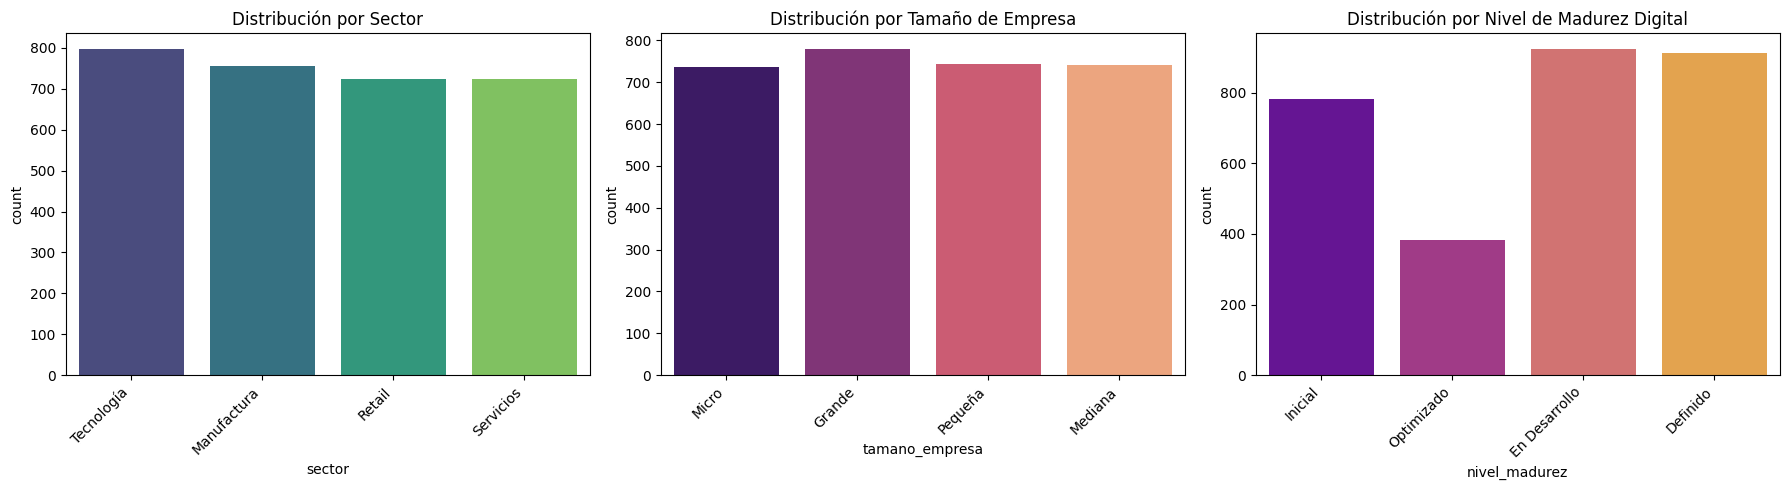

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['sector', 'tamano_empresa', 'nivel_madurez']

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='sector', palette='viridis', hue='sector', legend=False)
plt.title('Distribución por Sector')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='tamano_empresa', palette='magma', hue='tamano_empresa', legend=False)
plt.title('Distribución por Tamaño de Empresa')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='nivel_madurez', palette='plasma', hue='nivel_madurez', legend=False)
plt.title('Distribución por Nivel de Madurez Digital')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Análisis de columnas numéricas: Distribución y Outliers

/tmp/ipykernel_1178/3735810021.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_1178/3735810021.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='magma')
/tmp/ipykernel_1178/3735810021.py:7: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df[col], kde=True, bins=30, palette='viridis')
/tmp/ipykernel_1178/3735810021.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df[col], palette='magma')


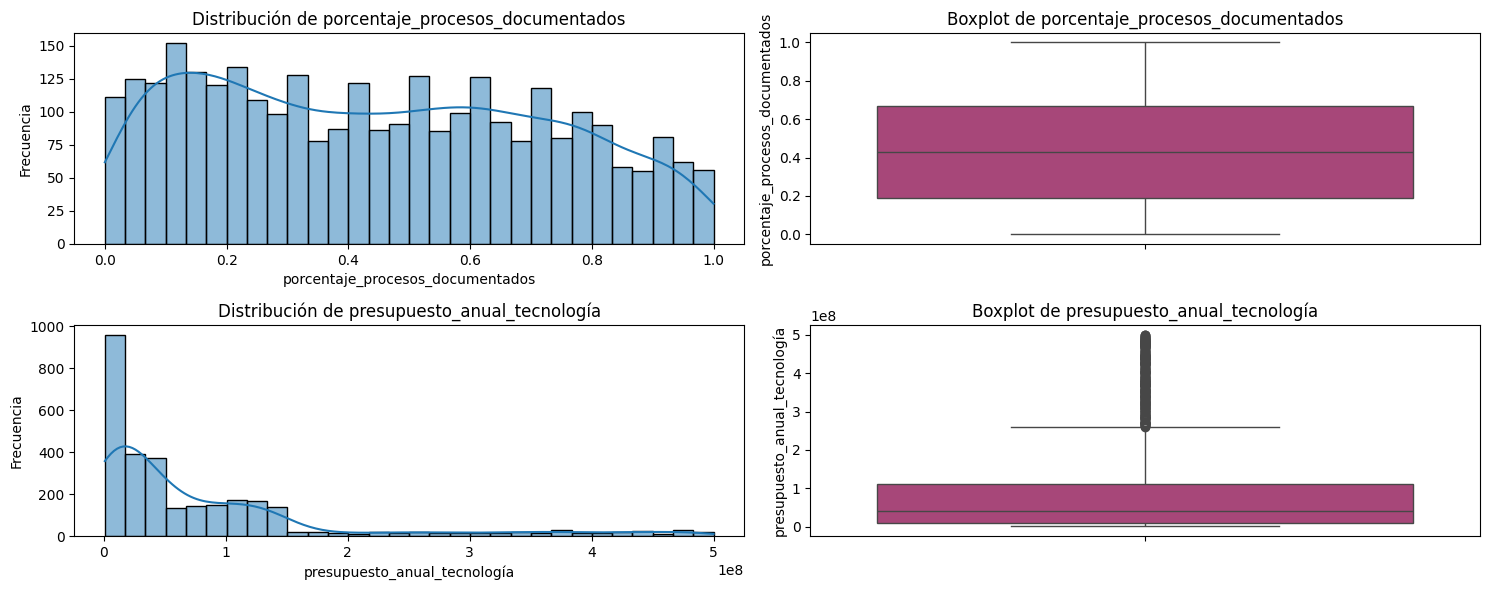

In [ ]:
numerical_cols = ['porcentaje_procesos_documentados', 'presupuesto_anual_tecnología']

plt.figure(figsize=(15, 6))

for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, 2*i + 1)
    sns.histplot(df[col], kde=True, bins=30, palette='viridis')
    plt.title(f'Distribución de {col}')
    plt.xlabel(col)
    plt.ylabel('Frecuencia')

    plt.subplot(2, 2, 2*i + 2)
    sns.boxplot(y=df[col], palette='magma')
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

### Relación entre el Nivel de Madurez Digital y las variables numéricas

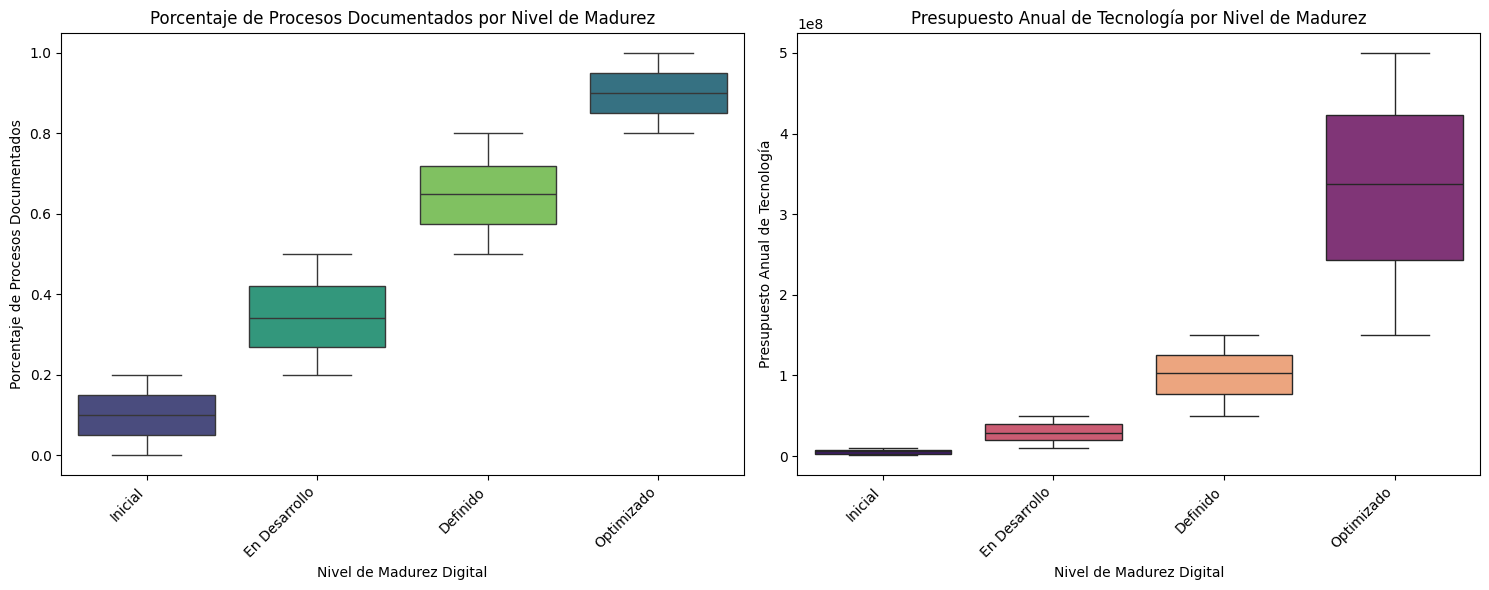

In [ ]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='nivel_madurez', y='porcentaje_procesos_documentados', palette='viridis', order=['Inicial', 'En Desarrollo', 'Definido', 'Optimizado'], hue='nivel_madurez', legend=False)
plt.title('Porcentaje de Procesos Documentados por Nivel de Madurez')
plt.xlabel('Nivel de Madurez Digital')
plt.ylabel('Porcentaje de Procesos Documentados')
plt.xticks(rotation=45, ha='right')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='nivel_madurez', y='presupuesto_anual_tecnología', palette='magma', order=['Inicial', 'En Desarrollo', 'Definido', 'Optimizado'], hue='nivel_madurez', legend=False)
plt.title('Presupuesto Anual de Tecnología por Nivel de Madurez')
plt.xlabel('Nivel de Madurez Digital')
plt.ylabel('Presupuesto Anual de Tecnología')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

### Relación entre variables categóricas: Sector, Tamaño de Empresa y Nivel de Madurez

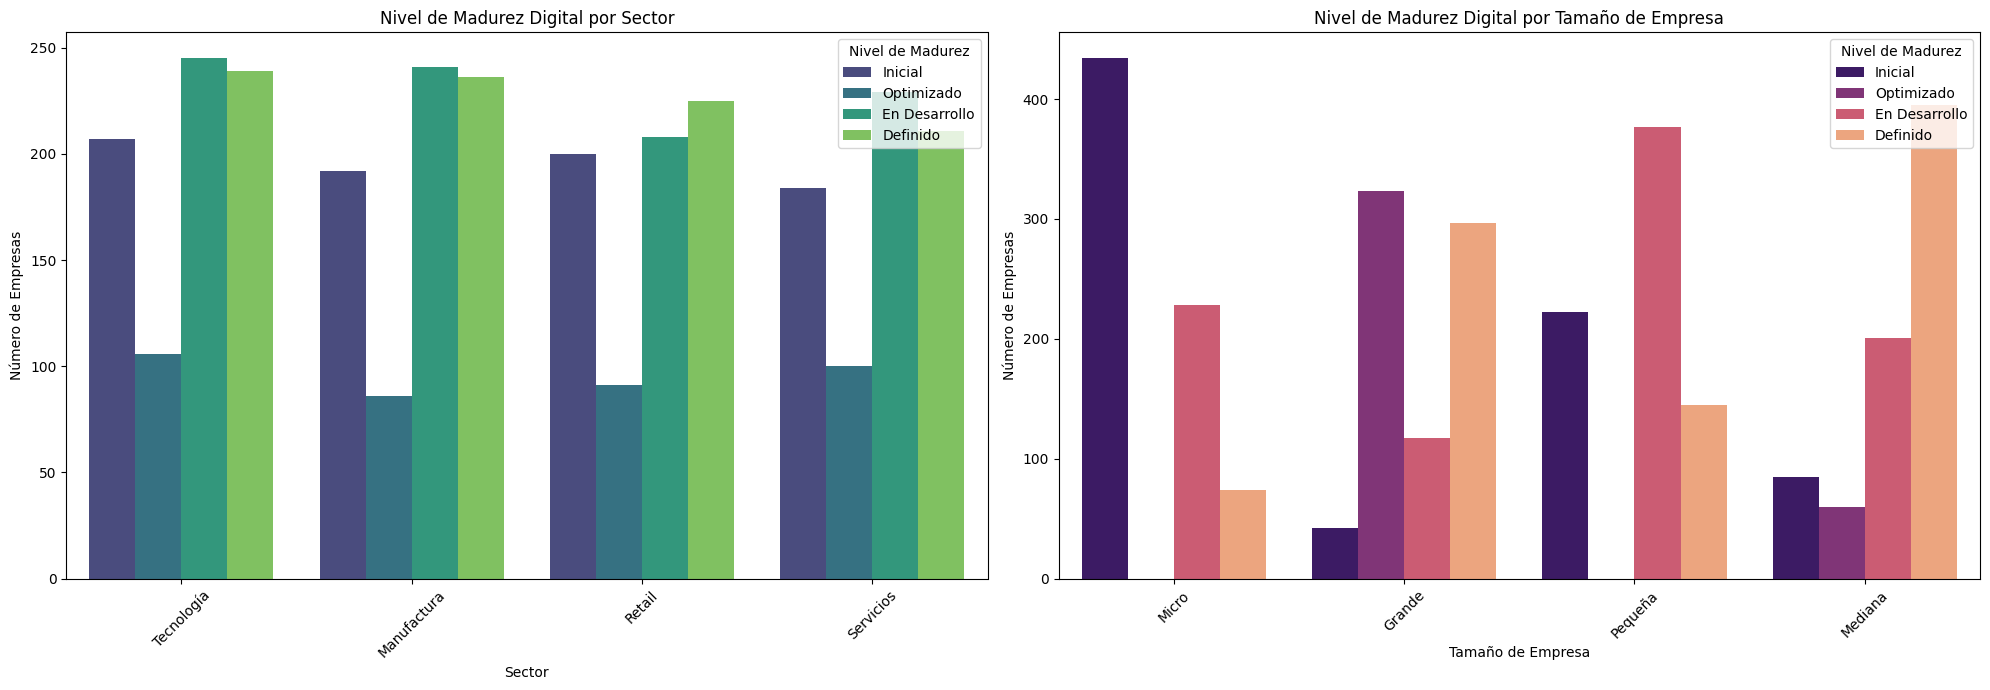

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

sns.countplot(data=df, x='sector', hue='nivel_madurez', palette='viridis', ax=axes[0])
axes[0].set_title('Nivel de Madurez Digital por Sector')
axes[0].set_xlabel('Sector')
axes[0].set_ylabel('Número de Empresas')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title='Nivel de Madurez', loc='upper right')

sns.countplot(data=df, x='tamano_empresa', hue='nivel_madurez', palette='magma', ax=axes[1])
axes[1].set_title('Nivel de Madurez Digital por Tamaño de Empresa')
axes[1].set_xlabel('Tamaño de Empresa')
axes[1].set_ylabel('Número de Empresas')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Nivel de Madurez', loc='upper right')

plt.tight_layout()
plt.show()

### Matriz de correlación para variables numéricas (si hubiera más de dos)

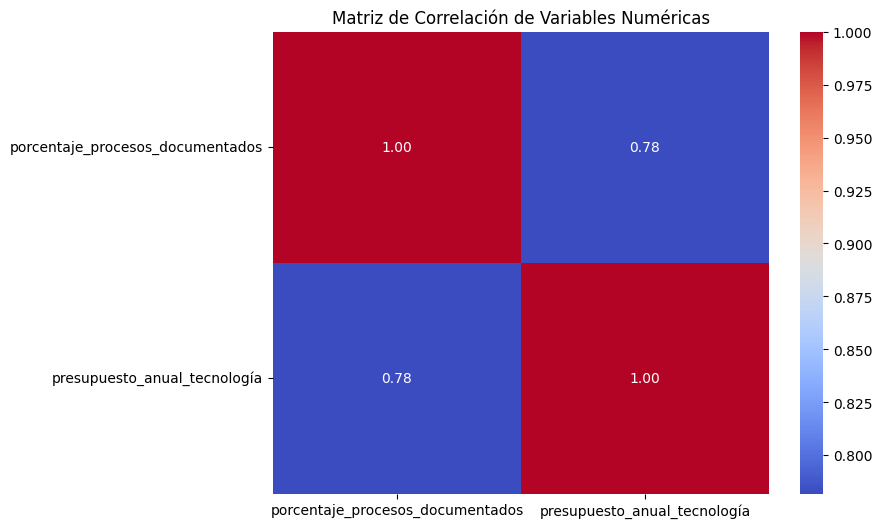

In [ ]:
numerical_df = df[numerical_cols]

if len(numerical_cols) > 1:
    correlation_matrix = numerical_df.corr()
    plt.figure(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlación de Variables Numéricas')
    plt.show()
else:
    print("Se necesita más de una variable numérica para calcular la matriz de correlación.")